# Data Cleaning & Exploration
Welcome to the sixth lesson! This Jupyter Notebook file is meant to accompany **L06 - Data Cleaning & Exploration.**

Type your solutions for each exercise in the code cells below, and then press **Shift + Enter** to execute your code. Then, check the solution video to see how you did!

### 1. The Machine Learning Process

### 2. Introduction to Matplotlib and Seaborn

### 3. Correcting Categorical Features

<font color = 'blue'> **EXERCISE 3.1** </font>

In [1]:
# Import NumPy, Pandas, Pyplot (from Matplotlib), and Seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import tight_layout



In [2]:
# Import Stock Data.csv into a new DataFrame
stock_data = pd.read_csv('../data/raw/stock_data_v2.csv')

# Display the first row
stock_data.head(1)


,Ticker,Name,Sector,Beta,Market Cap,Current Price,Price Target,Price Increase,Return
0,AAPL,APPLE INC,Information Technology,1.09,1081130615,223.84,232.27,8.43,0.038


![Exercise 3.1](../figures/exercise_3_1.png)

In [3]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ticker          100 non-null    object 
 1   Name            100 non-null    object 
 2   Sector          93 non-null     object 
 3   Beta            100 non-null    float64
 4   Market Cap      100 non-null    int64  
 5   Current Price   100 non-null    float64
 6   Price Target    93 non-null     float64
 7   Price Increase  93 non-null     float64
 8   Return          93 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 7.2+ KB


In [4]:
# Display the unique values in 'Sector'
stock_data['Sector'].unique()


array(['Information Technology', 'Consumer Discretionary', 'Financials',
       'Health Care', 'Energy', 'Consumer Staples', nan,
       'Telecommunication Services', 'Industrials',
       'Information Technology .', 'Materials', 'Industrial$',
       'Utilities', 'Enersy', 'lndustrials', 'Real Estate'], dtype=object)

<font color = 'blue'> **EXERCISE 3.2** </font>

![Exercise 3.2](../figures/exercise_3_2.png)

In [5]:
# dataframe info
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ticker          100 non-null    object 
 1   Name            100 non-null    object 
 2   Sector          93 non-null     object 
 3   Beta            100 non-null    float64
 4   Market Cap      100 non-null    int64  
 5   Current Price   100 non-null    float64
 6   Price Target    93 non-null     float64
 7   Price Increase  93 non-null     float64
 8   Return          93 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 7.2+ KB


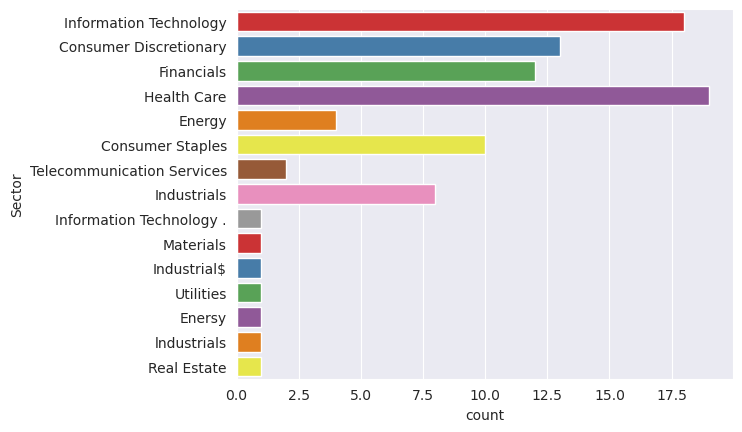

In [6]:
sns.countplot(y='Sector', data=stock_data, hue='Sector', palette='Set1') # hue='Sector'  is what provides multiple colors in the plot The palette= is setting a predefined pattern
plt.legend().remove()
plt.show()

<font color = 'blue'> **EXERCISE 3.3** </font>

![Exercise 3.3](../figures/exercise_3_3.png)

In [7]:
stock_data['Sector'] = stock_data['Sector'].replace({
    'Information Technology .': 'Information Technology',
    'Enersy': 'Energy',
    'Industrial$': 'Industrials',
    'lndustrials': 'Industrials'
},
regex=True
)
stock_data['Sector'].unique()

array(['Information Technology', 'Consumer Discretionary', 'Financials',
       'Health Care', 'Energy', 'Consumer Staples', nan,
       'Telecommunication Services', 'Industrials', 'Materials',
       'Industrial$', 'Utilities', 'Real Estate'], dtype=object)

<font color = 'blue'> **EXERCISE 3.4** </font>

![Exercise 3.4](../figures/exercise_3_4.png)

In [8]:
stock_data['Sector'] = stock_data['Sector'].replace({
    'Materials': 'Industrials',
    'Telecommunication Services': 'Other',
    'Utilities': 'Other',
    'Real Estate': 'Other'
})
stock_data['Sector'].unique()

array(['Information Technology', 'Consumer Discretionary', 'Financials',
       'Health Care', 'Energy', 'Consumer Staples', nan, 'Other',
       'Industrials', 'Industrial$'], dtype=object)

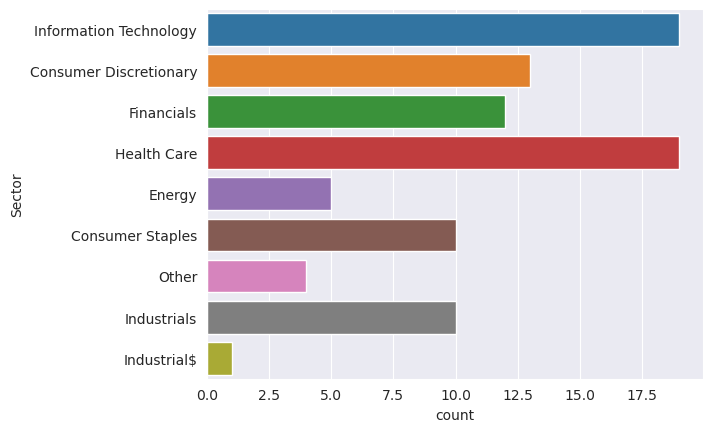

In [9]:
sns.countplot(y='Sector', data=stock_data, hue='Sector', legend=False)
plt.show()

### 4. Outliers & Unwanted Observations

<font color = 'blue'> **EXERCISE 4.1** </font>

![Exercise 4.1](../figures/exercise_4_1.png)

In [10]:
# Display the dimensions of the stock_data DataFrame

stock_data.shape

(100, 9)

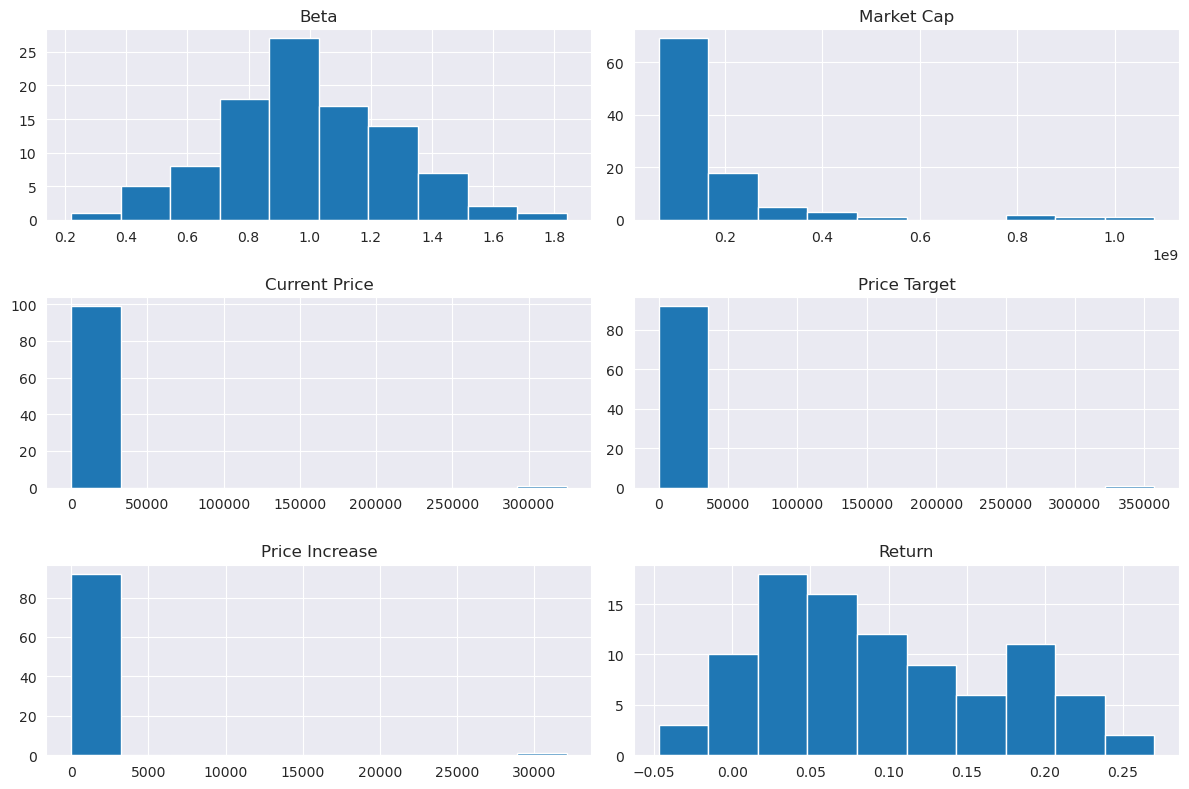

In [11]:
# Display histograms for all continuous features

stock_data.hist(figsize=(12,8))
# for quick and easy where pyplot controls the spacing between graphs
plt.tight_layout() # I think this ends up looking much better

# For manual control of the spacing between graphs
# hspace → vertical spacing between plots
# wspace → horizontal spacing
# plt.subplots_adjust(hspace=0.6, wspace=0.6)

# Show the plot
plt.show()


## Analysis of Histogram
- Beta is a normal distribution
- Seems to be an outlier that is far greater than others.
- The outlier should be examined to determine if it is an error, should be included, or should be excluded

<font color = 'blue'> **EXERCISE 4.2** </font>

![Exercise 4.2](../figures/exercise_4_2.png)

In [12]:
stock_data.info

<bound method DataFrame.info of    Ticker              Name                  Sector  Beta  Market Cap  \
0    AAPL         APPLE INC  Information Technology  1.09  1081130615   
1    AMZN    AMAZON.COM INC  Consumer Discretionary  1.23   960942834   
2    MSFT    MICROSOFT CORP  Information Technology  1.46   869345788   
3   GOOGL    ALPHABET INC-A  Information Technology  1.44   817459888   
4   BRK/A  BERKSHIRE HATH-A              Financials  1.13   534247506   
..    ...               ...                     ...   ...         ...   
95    AMT  AMERICAN TOWER C                   Other  0.46    64886514   
96   ISRG  INTUITIVE SURGIC             Health Care  1.32    64649581   
97    ADP    AUTOMATIC DATA  Information Technology  0.96    64599683   
98   MOLZ  MONDELEZ INTER-A        Consumer Staples  0.74    64235373   
99    AGN      ALLERGAN PLC             Health Care  1.01    63890227   

    Current Price  Price Target  Price Increase  Return  
0          223.84        232.27  

In [13]:
price_above_5k = (stock_data['Current Price'] > 5000).astype(int)
price_above_5k.value_counts()

Current Price
0    99
1     1
Name: count, dtype: int64

In [14]:
stock_data['is_price_above_5k'] = price_above_5k
stock_data.head(1)

,Ticker,Name,Sector,Beta,Market Cap,Current Price,Price Target,Price Increase,Return,is_price_above_5k
0,AAPL,APPLE INC,Information Technology,1.09,1081130615,223.84,232.27,8.43,0.038,0


In [15]:
stock_data['is_price_above_5k']

0     0
1     0
2     0
3     0
4     1
     ..
95    0
96    0
97    0
98    0
99    0
Name: is_price_above_5k, Length: 100, dtype: int64

In [16]:
stock_data[price_above_5k == 1]

,Ticker,Name,Sector,Beta,Market Cap,Current Price,Price Target,Price Increase,Return,is_price_above_5k
4,BRK/A,BERKSHIRE HATH-A,Financials,1.13,534247506,324999.0,357125.0,32126.0,0.099,1


<font color = 'blue'> **EXERCISE 4.3a** </font>

![Exercise 4.3a](../figures/exercise_4_3a.png)

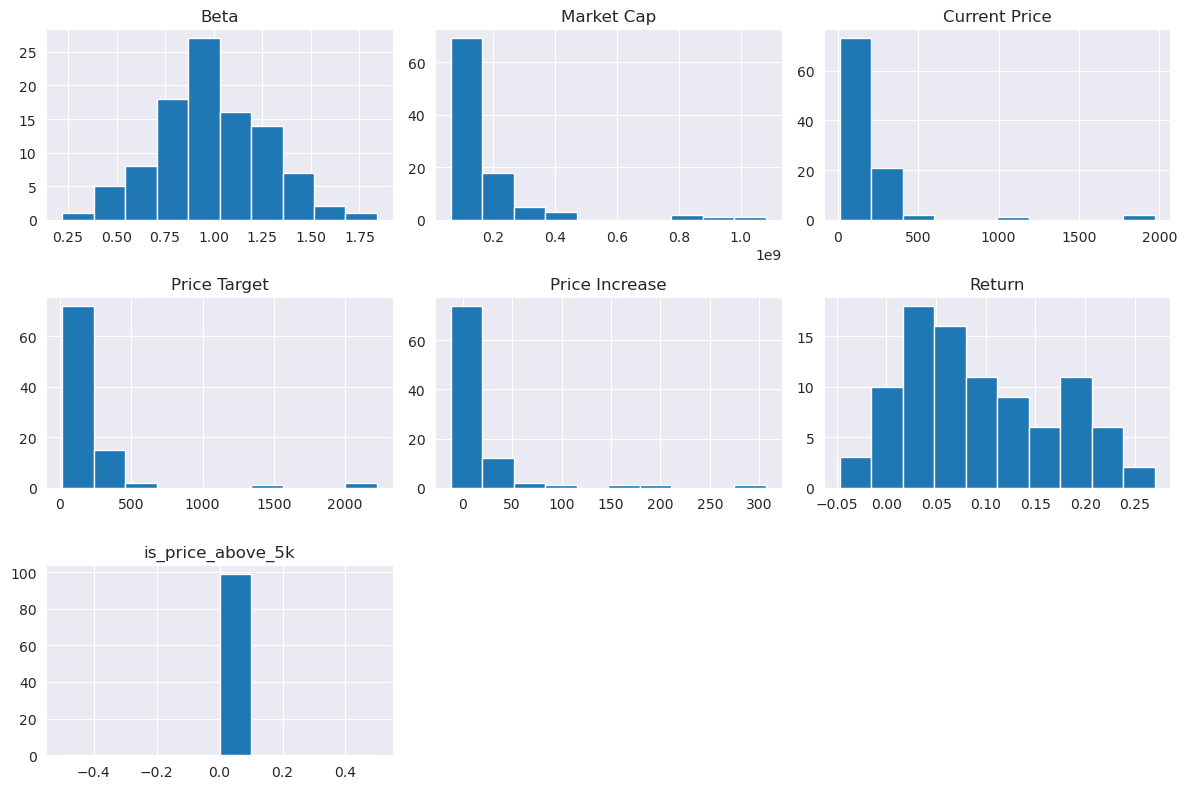

In [17]:
stock_data[stock_data['is_price_above_5k'] == 0].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


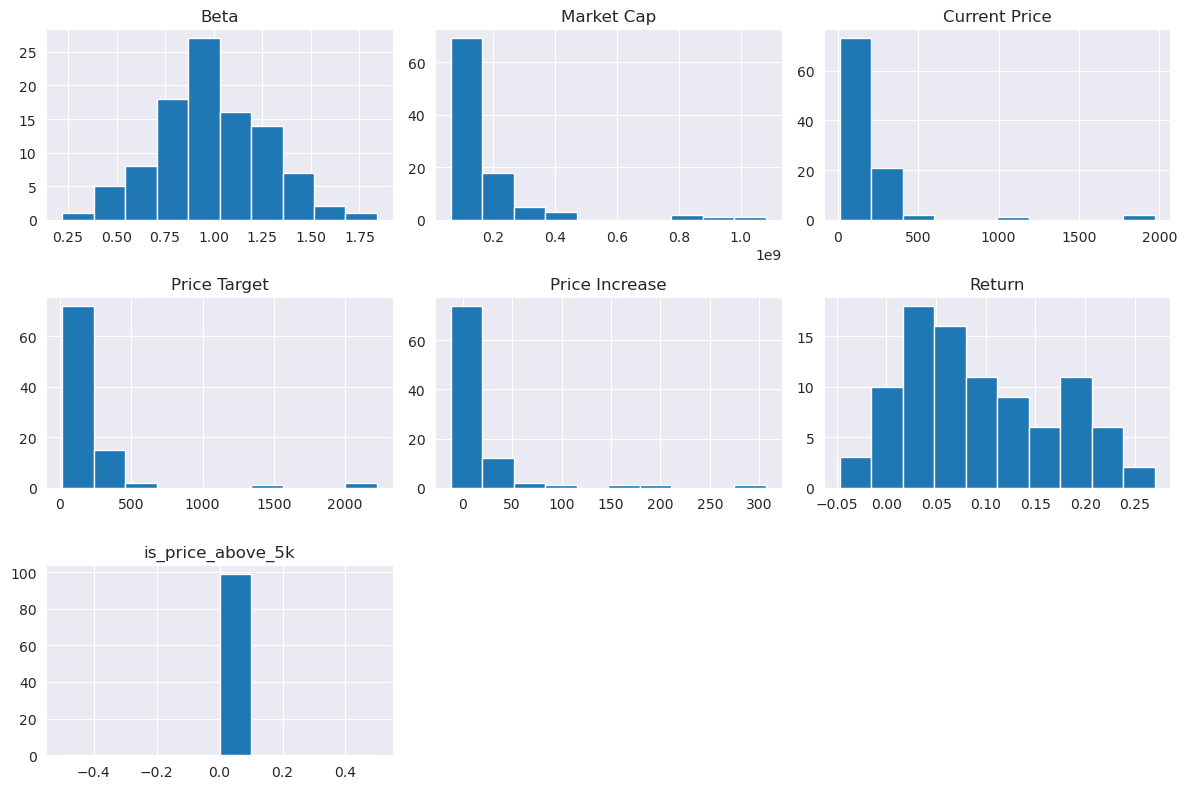

In [18]:
stock_data_wout_sans_brk = stock_data[stock_data['Current Price'] < 300000]
stock_data_wout_sans_brk.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

<font color = 'blue'> **EXERCISE 4.3b** </font>

![Exercise 4.3b](../figures/exercise_4_3b.png)

<font color = 'blue'> **EXERCISE 4.4** </font>

<font color = 'blue'> **EXERCISE 4.5** </font>

<font color = 'blue'> **EXERCISE 4.6** </font>

<font color = 'blue'> **EXERCISE 4.7** </font>

In [ ]:
# Display the box distribution of 'Beta' by 'Sector'



In [ ]:
# Display the box distribution of 'Return' by 'Sector'

